# PTEN Variant Abundance: Coverage & Score Statistics

Analysis of `pten-variant-abundance.csv` across all 403 positions of the PTEN protein. Covers:
1. Coverage (missense variants observed) at every position, including positions with none
2. Per-position score statistics, restricted to positions with enough data
3. Test functions that check the above and reject unexpected input
4. Visualization of both across the protein sequence

In [ ]:
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## Load and validate the data

`load_variant_data` parses the protein position out of each `hgvs_pro` string (e.g. `p.His75Ala` → position 75) and validates as it goes: rejects rows it can't parse, positions outside 1–403, duplicate variants, and non-numeric scores, instead of silently dropping or miscoding them.

In [ ]:
N_POSITIONS = 403  # length of the PTEN reference sequence used here

HGVS_PRO_PATTERN = re.compile(r"^p\.[A-Za-z]{3}(\d+)[A-Za-z=*]+$")


def parse_position(hgvs_pro):
    """Extract the 1-indexed protein position from e.g. 'p.His75Ala'.
    Returns None for anything that doesn't match that shape (e.g. the
    '_wt' placeholder used for the wild-type reference record)."""
    if pd.isna(hgvs_pro):
        return None
    match = HGVS_PRO_PATTERN.match(hgvs_pro)
    if not match:
        return None
    return int(match.group(1))


def load_variant_data(csv_path, n_positions=N_POSITIONS):
    """Load the variant CSV, parse each row's protein position, and
    validate the result. Raises rather than silently dropping/miscounting
    rows when something doesn't look right."""
    df = pd.read_csv(csv_path)

    required_cols = {"hgvs_pro", "score", "record_type"}
    missing_cols = required_cols - set(df.columns)
    if missing_cols:
        raise ValueError(f"Input data is missing required column(s): {missing_cols}")

    df = df.copy()
    df["position"] = df["hgvs_pro"].apply(parse_position)

    # Every row should be placeable at a position, except the single
    # wild-type reference record (hgvs_pro == '_wt').
    unplaced = df["position"].isna() & (df["record_type"] != "wild_type")
    if unplaced.any():
        bad = df.loc[unplaced, "hgvs_pro"].tolist()
        raise ValueError(f"Could not parse a position from hgvs_pro value(s): {bad}")

    placed = df["position"].notna()
    out_of_range = placed & ((df["position"] < 1) | (df["position"] > n_positions))
    if out_of_range.any():
        bad = df.loc[out_of_range, ["hgvs_pro", "position"]]
        raise ValueError(f"Found position(s) outside the expected 1-{n_positions} range:\n{bad}")

    dup = df.loc[placed, "hgvs_pro"].duplicated()
    if dup.any():
        raise ValueError(f"Duplicate hgvs_pro entries found: {df.loc[placed, 'hgvs_pro'][dup].tolist()}")

    if not pd.api.types.is_numeric_dtype(df["score"]):
        raise TypeError("`score` column must be numeric")

    return df


df = load_variant_data("pten-variant-abundance.csv")
print(f"Loaded {len(df)} rows covering {df['record_type'].nunique()} record types:")
print(df["record_type"].value_counts().to_string())


Loaded 4409 rows covering 4 record types:
record_type
missense      4112
synonymous     156
nonsense       140
wild_type        1


## 1. Coverage across all 403 positions

`compute_coverage` counts observed missense substitutions at every position from 1–403, filling in **0** (a real, known value) for positions with none — nothing gets dropped from the report.

In [ ]:
def compute_coverage(df, n_positions=N_POSITIONS, variant_type="missense"):
    """Count observed substitutions of `variant_type` at every position
    from 1 to n_positions. Positions with none observed get 0 -- they're
    included, not dropped, which is the whole point of a coverage report."""
    subset = df[df["record_type"] == variant_type]
    counts = subset.groupby("position").size()
    coverage = counts.reindex(range(1, n_positions + 1), fill_value=0).astype(int)
    coverage.index.name = "position"
    coverage.name = "n_variants"
    return coverage


coverage = compute_coverage(df)

n_zero = int((coverage == 0).sum())
print(f"Coverage computed for all {len(coverage)} positions.")
print(f"Positions with at least 1 observed missense variant: {len(coverage) - n_zero}")
print(f"Positions with ZERO observed missense variants:      {n_zero}")
print()
print("Coverage summary statistics (variants observed per position):")
print(coverage.describe().round(2).to_string())
print()
print("Positions with zero coverage:")
print(coverage[coverage == 0].index.tolist())


Coverage computed for all 403 positions.
Positions with at least 1 observed missense variant: 360
Positions with ZERO observed missense variants:      43

Coverage summary statistics (variants observed per position):
count    403.00
mean      10.20
std        5.71
min        0.00
25%        6.00
50%       12.00
75%       15.00
max       19.00

Positions with zero coverage:
[8, 32, 33, 34, 41, 42, 70, 99, 101, 113, 132, 150, 169, 173, 180, 181, 183, 185, 190, 198, 200, 221, 251, 267, 283, 290, 291, 301, 302, 317, 323, 324, 326, 327, 328, 350, 352, 353, 359, 373, 374, 381, 382]


## 2. Score statistics per position (`minimum_variants = 5`)

`compute_score_statistics` computes mean/median/std/min/max per position, but **only** where at least `minimum_variants` substitutions were observed. Below that threshold — including true zero-coverage positions — the statistic columns are `NaN`, while `n_variants` stays a real integer. That keeps *"no data"* (`n_variants == 0`) distinct from *"not enough data to trust a statistic"* (`NaN`); folding both into 0 would make a low-coverage position look like it scored zero, which it didn't — it just wasn't measured enough.

In [ ]:
def compute_score_statistics(df, minimum_variants=5, n_positions=N_POSITIONS, variant_type="missense"):
    """Per-position score statistics (n, mean, median, std, min, max),
    computed only for positions with >= minimum_variants observations.

    n_variants is always a real integer -- 0 if nothing was observed at
    that position. The statistic columns (mean/median/std/min/max) are
    NaN wherever n_variants < minimum_variants, including positions with
    zero coverage. That keeps "no data" (n_variants == 0, a known zero)
    distinct from "not enough data to trust a statistic" (NaN, meaning
    not computed) -- collapsing the two into a single 0 would silently
    misrepresent low-coverage positions as having a score of zero.
    """
    if not isinstance(minimum_variants, (int, np.integer)) or minimum_variants < 1:
        raise ValueError("minimum_variants must be a positive integer")

    subset = df[df["record_type"] == variant_type]

    if subset["score"].isna().any():
        n_missing = int(subset["score"].isna().sum())
        raise ValueError(
            f"{n_missing} {variant_type} row(s) have a missing score value; "
            "investigate before aggregating rather than silently dropping them"
        )

    grouped = subset.groupby("position")["score"]
    n_variants = grouped.size()

    stats = pd.DataFrame({
        "n_variants": n_variants,
        "mean": grouped.mean(),
        "median": grouped.median(),
        "std": grouped.std(),
        "min": grouped.min(),
        "max": grouped.max(),
    })

    stats = stats.reindex(range(1, n_positions + 1))
    stats["n_variants"] = stats["n_variants"].fillna(0).astype(int)

    below_threshold = stats["n_variants"] < minimum_variants
    stat_cols = ["mean", "median", "std", "min", "max"]
    stats.loc[below_threshold, stat_cols] = np.nan

    stats.index.name = "position"
    return stats


MINIMUM_VARIANTS = 5
stats = compute_score_statistics(df, minimum_variants=MINIMUM_VARIANTS)

n_qualifying = int(stats["mean"].notna().sum())
print(f"minimum_variants = {MINIMUM_VARIANTS}")
print(f"Positions with a computed score statistic: {n_qualifying} / {len(stats)}")
print(f"Positions excluded (too few or zero variants): {len(stats) - n_qualifying}")
print()
print("Example: a zero-coverage position vs. a below-threshold position vs. a qualifying one")
print(stats.loc[[8, 3, 75]])
print()
print("n_variants is never NaN (always a known count); confirm:", stats["n_variants"].isna().sum(), "NaNs")
stats.head(10)


minimum_variants = 5
Positions with a computed score statistic: 317 / 403
Positions excluded (too few or zero variants): 86

Example: a zero-coverage position vs. a below-threshold position vs. a qualifying one
          n_variants      mean    median       std       min      max
position                                                             
8                  0       NaN       NaN       NaN       NaN      NaN
3                  3       NaN       NaN       NaN       NaN      NaN
75                13  0.987643  1.002307  0.103006  0.752984  1.10165

n_variants is never NaN (always a known count); confirm: 0 NaNs


## 3. Test functions

No `pytest` dependency (this environment has had repeated trouble getting packages into the right kernel) — each `test_*` function is a plain function using `assert`, and `run_all_tests()` collects and reports results. Covers: coverage including zero positions, correct counts against a hand-checked toy example, the NaN-vs-zero distinction, correct statistic values, inclusive threshold boundary, and rejection of bad `minimum_variants`, missing scores, unparseable `hgvs_pro`, out-of-range positions, and duplicate entries.

In [ ]:
def _toy_df():
    """Small synthetic dataset standing in for the real 403 positions:
      - position 1: 5 missense variants (meets minimum_variants=5)
      - position 2: 2 missense variants (below threshold)
      - position 3: 0 missense variants (no coverage at all)
      - position 4: 1 synonymous variant only (shouldn't count as missense coverage)
      - position 5: 6 missense variants (above threshold)
      - position 6: 0 missense variants
    """
    rows = [
        ("p.Ala1Gly", 1.0, "missense"), ("p.Ala1Ser", 1.2, "missense"),
        ("p.Ala1Thr", 0.8, "missense"), ("p.Ala1Val", 1.1, "missense"),
        ("p.Ala1Cys", 0.9, "missense"),
        ("p.Gly2Ala", 0.5, "missense"), ("p.Gly2Ser", 0.6, "missense"),
        ("p.Leu4=", 1.0, "synonymous"),
        ("p.Trp5Ala", 2.0, "missense"), ("p.Trp5Cys", 2.2, "missense"),
        ("p.Trp5Gly", 1.8, "missense"), ("p.Trp5Ser", 2.1, "missense"),
        ("p.Trp5Thr", 1.9, "missense"), ("p.Trp5Val", 2.0, "missense"),
    ]
    d = pd.DataFrame(rows, columns=["hgvs_pro", "score", "record_type"])
    d["position"] = d["hgvs_pro"].apply(parse_position)
    return d


def test_coverage_includes_zero_positions():
    cov = compute_coverage(_toy_df(), n_positions=6)
    assert len(cov) == 6
    assert cov.loc[3] == 0 and cov.loc[6] == 0


def test_coverage_counts_match_expected():
    cov = compute_coverage(_toy_df(), n_positions=6)
    expected = {1: 5, 2: 2, 3: 0, 4: 0, 5: 6, 6: 0}
    for pos, exp_n in expected.items():
        assert cov.loc[pos] == exp_n


def test_coverage_ignores_non_missense_by_default():
    cov = compute_coverage(_toy_df(), n_positions=6)
    assert cov.loc[4] == 0  # only a synonymous variant sits here


def test_stats_below_threshold_are_nan_not_zero():
    stats = compute_score_statistics(_toy_df(), minimum_variants=5, n_positions=6)
    assert stats.loc[2, "n_variants"] == 2 and np.isnan(stats.loc[2, "mean"])
    assert stats.loc[3, "n_variants"] == 0 and np.isnan(stats.loc[3, "mean"])


def test_stats_n_variants_never_nan():
    stats = compute_score_statistics(_toy_df(), minimum_variants=5, n_positions=6)
    assert not stats["n_variants"].isna().any()


def test_stats_values_correct_for_known_position():
    stats = compute_score_statistics(_toy_df(), minimum_variants=5, n_positions=6)
    expected_mean = np.mean([1.0, 1.2, 0.8, 1.1, 0.9])
    assert np.isclose(stats.loc[1, "mean"], expected_mean)
    assert np.isclose(stats.loc[1, "min"], 0.8) and np.isclose(stats.loc[1, "max"], 1.2)


def test_stats_threshold_boundary_is_inclusive():
    stats_incl = compute_score_statistics(_toy_df(), minimum_variants=2, n_positions=6)
    assert not np.isnan(stats_incl.loc[2, "mean"])
    stats_excl = compute_score_statistics(_toy_df(), minimum_variants=3, n_positions=6)
    assert np.isnan(stats_excl.loc[2, "mean"])


def test_rejects_non_positive_minimum_variants():
    for bad_value in (0, -1, 2.5, "5"):
        try:
            compute_score_statistics(_toy_df(), minimum_variants=bad_value, n_positions=6)
        except (ValueError, TypeError):
            continue
        raise AssertionError(f"minimum_variants={bad_value!r} should have been rejected")


def test_rejects_missing_scores():
    toy = _toy_df()
    toy.loc[0, "score"] = np.nan
    try:
        compute_score_statistics(toy, minimum_variants=5, n_positions=6)
    except ValueError:
        return
    raise AssertionError("a missing score should be flagged, not silently dropped")


def test_rejects_unparseable_hgvs_pro():
    import tempfile, os
    toy = _toy_df().drop(columns=["position"])
    toy.loc[0, "hgvs_pro"] = "not_a_real_variant"
    with tempfile.TemporaryDirectory() as d:
        path = os.path.join(d, "bad.csv")
        toy.to_csv(path, index=False)
        try:
            load_variant_data(path, n_positions=6)
        except ValueError:
            return
    raise AssertionError("an unparseable hgvs_pro string should be rejected on load")


def test_rejects_out_of_range_position():
    import tempfile, os
    toy = _toy_df().drop(columns=["position"])
    toy.loc[0, "hgvs_pro"] = "p.Ala999Gly"
    with tempfile.TemporaryDirectory() as d:
        path = os.path.join(d, "bad.csv")
        toy.to_csv(path, index=False)
        try:
            load_variant_data(path, n_positions=6)
        except ValueError:
            return
    raise AssertionError("a position outside the expected range should be rejected on load")


def test_rejects_duplicate_hgvs_pro():
    import tempfile, os
    toy = _toy_df().drop(columns=["position"])
    toy.loc[1, "hgvs_pro"] = toy.loc[0, "hgvs_pro"]
    with tempfile.TemporaryDirectory() as d:
        path = os.path.join(d, "bad.csv")
        toy.to_csv(path, index=False)
        try:
            load_variant_data(path, n_positions=6)
        except ValueError:
            return
    raise AssertionError("a duplicate hgvs_pro entry should be rejected on load")


def run_all_tests():
    tests = [obj for name, obj in list(globals().items()) if name.startswith("test_")]
    passed, failed = 0, []
    for t in tests:
        try:
            t()
            passed += 1
        except AssertionError as e:
            failed.append((t.__name__, str(e)))
        except Exception as e:
            failed.append((t.__name__, f"{type(e).__name__}: {e}"))
    print(f"{passed}/{len(tests)} tests passed")
    for name, msg in failed:
        print(f"  FAILED {name}: {msg}")
    return len(failed) == 0


run_all_tests()


12/12 tests passed


## 4. Visualization (heatmap)

403 positions wrapped into a 13x31 grid (13 x 31 = 403 exactly, no padding needed), read left-to-right then top-to-bottom, so each row covers a contiguous stretch of ~31 residues. Top: coverage, colored by variants observed (dark = fewer/none). Bottom: mean score, colored on a diverging scale centered at 1.0 (WT-like); positions excluded for insufficient data (n_variants < 5, including zero-coverage positions) are masked gray rather than colored as if they were real zeros.

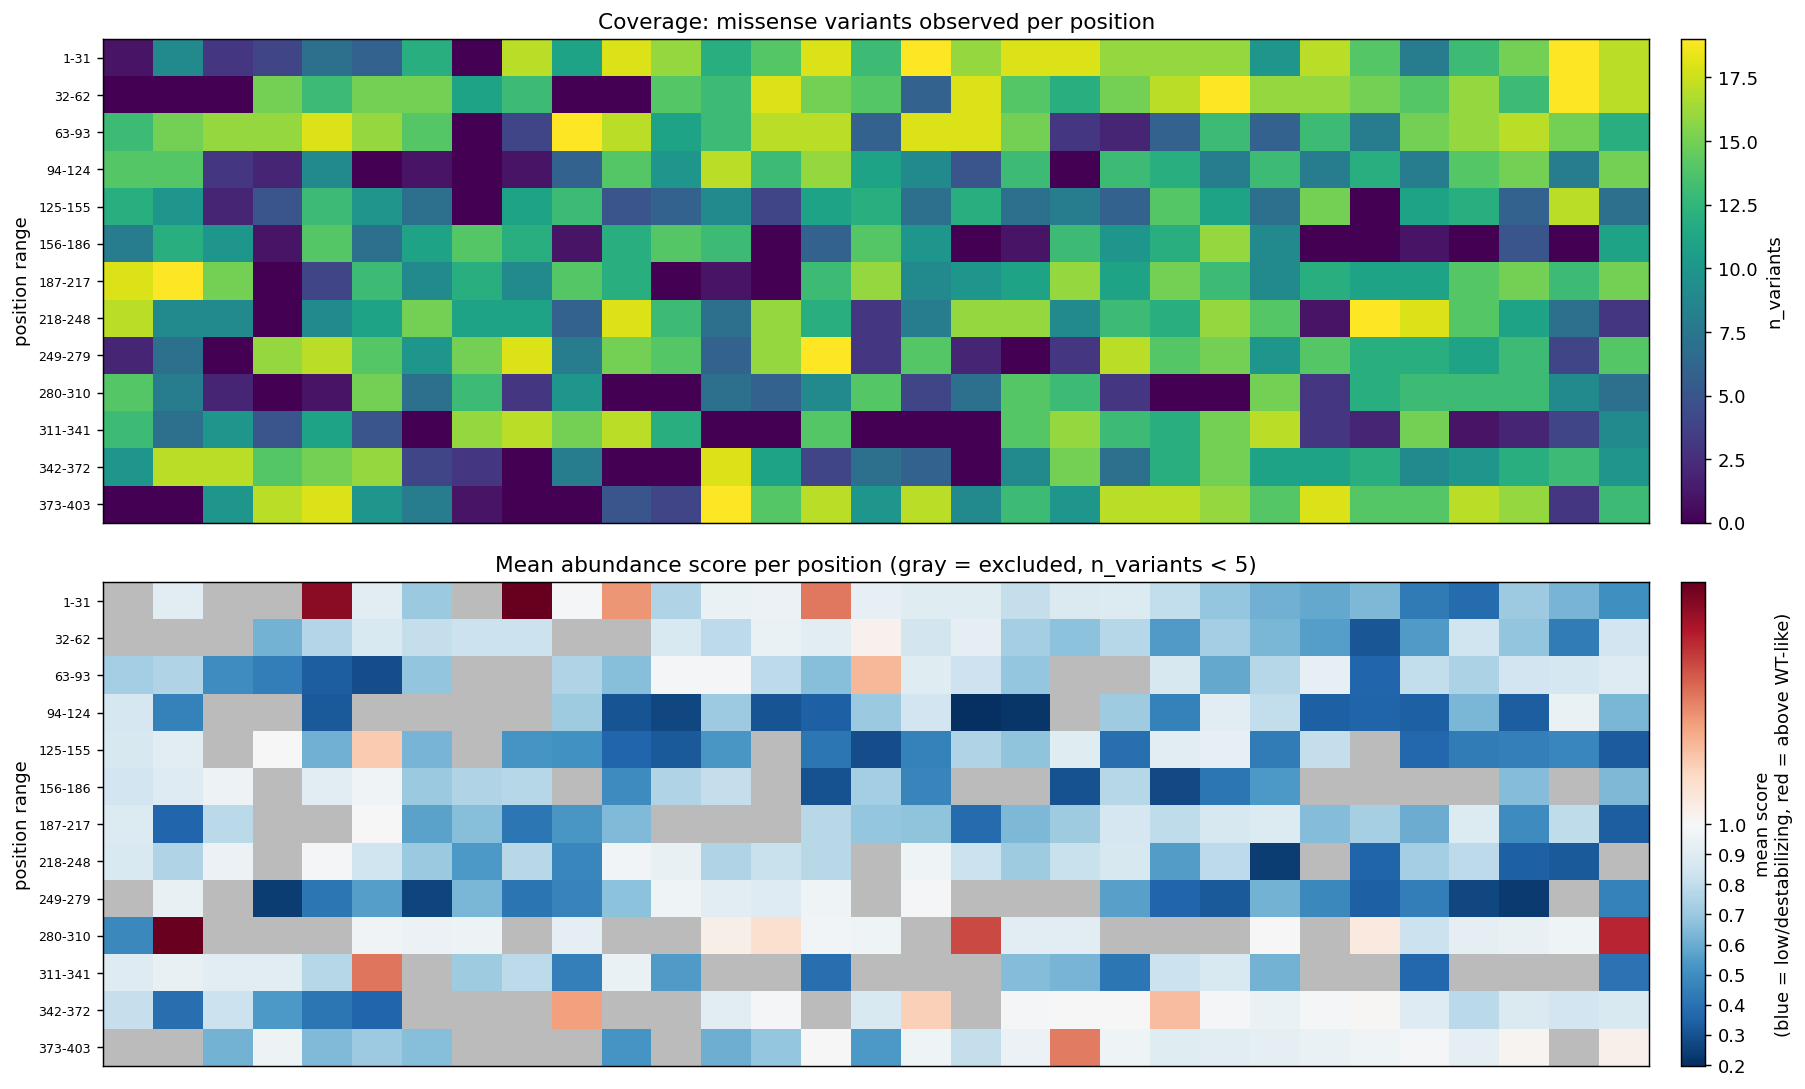

In [ ]:
import matplotlib.colors as mcolors

N_COLS = 31  # 403 = 13 x 31, so this wraps with no padding needed
N_ROWS = N_POSITIONS // N_COLS

cov_grid = coverage.values.reshape(N_ROWS, N_COLS)
mean_grid = stats["mean"].values.reshape(N_ROWS, N_COLS)

row_labels = [
    f"{r * N_COLS + 1}-{min((r + 1) * N_COLS, N_POSITIONS)}" for r in range(N_ROWS)
]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8.5))

# --- Coverage heatmap ---
im1 = ax1.imshow(cov_grid, cmap="viridis", aspect="auto")
ax1.set_title("Coverage: missense variants observed per position")
fig.colorbar(im1, ax=ax1, fraction=0.025, pad=0.02).set_label("n_variants")
ax1.set_yticks(range(N_ROWS))
ax1.set_yticklabels(row_labels, fontsize=7)
ax1.set_xticks([])
ax1.set_ylabel("position range")

# --- Score heatmap (excluded positions masked gray) ---
mean_masked = np.ma.masked_invalid(mean_grid)
cmap2 = plt.cm.RdBu_r.copy()
cmap2.set_bad(color="#bbbbbb")
norm = mcolors.TwoSlopeNorm(vmin=np.nanmin(mean_grid), vcenter=1.0, vmax=np.nanmax(mean_grid))
im2 = ax2.imshow(mean_masked, cmap=cmap2, norm=norm, aspect="auto")
ax2.set_title(f"Mean abundance score per position (gray = excluded, n_variants < {MINIMUM_VARIANTS})")
fig.colorbar(im2, ax=ax2, fraction=0.025, pad=0.02).set_label("mean score\n(blue = low/destabilizing, red = above WT-like)")
ax2.set_yticks(range(N_ROWS))
ax2.set_yticklabels(row_labels, fontsize=7)
ax2.set_xticks([])
ax2.set_ylabel("position range")

plt.tight_layout()
plt.show()
